# 06. Regularization, Bias-Variance, and Feature Selection

As operational machine-learning systems mature, the feature space usually expands faster than our confidence in it. Teams add lags, ratios, duplicates, interaction terms, and telemetry-derived proxies because each one might help. But as the design matrix widens, an unregularized model can start fitting accident rather than structure. In decision settings, that creates an operational problem. It produces unstable forecasts, noisy feature stories, and brittle monitoring requirements.

This notebook studies how regularization and feature selection help us control that problem. We return to a support-operations forecasting task, but this time we intentionally build a wider, more redundant feature space. The goal is to make the bias-variance tradeoff visible rather than abstract. We will see how ridge, lasso, and elastic net behave when the model is given too much freedom; how shrinkage can improve generalization even when it introduces some bias; and how compact feature sets can support maintainability without materially sacrificing predictive quality.

The notebook is organized around four ideas grounded in the literature: ridge regression was introduced to stabilize estimation under nonorthogonality (Hoerl & Kennard, 1970), lasso makes coefficient shrinkage sparse enough to perform variable selection directly (Tibshirani, 1996), elastic net was designed to combine sparsity with a grouping effect among correlated predictors (Zou & Hastie, 2005), and feature selection should be judged both by accuracy and by stability and practical usability (Li et al., 2017).

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain the bias-variance tradeoff in a predictive modeling workflow with many correlated features.
2. Describe the differences among ridge, lasso, and elastic net penalties in operational terms.
3. Tune regularization strength using a validation set rather than intuition alone.
4. Diagnose when an unregularized model is overfitting an expanded design matrix.
5. Compare filter, wrapper, and embedded feature-selection strategies for compact model construction.
6. Interpret sparse model outputs carefully, distinguishing predictive usefulness from causal importance.


## 1. Why Regularization and Selection Matter

A wide feature space creates two different but related pressures. First, we may need **regularization** so that the fitted model does not overreact to quirks of the training sample. Second, we may need **feature selection** so that the resulting system is easier to monitor, explain, and maintain.

| Tool | What it changes | Bias effect | Variance effect | Why a decision-science team uses it |
|---|---|---|---|---|
| Unregularized least squares | No penalty on coefficient size | Lowest among these linear options | Highest when features are wide or collinear | Useful as a reference point, but often fragile |
| Ridge (`L2`) | Shrinks all coefficients toward zero | Adds modest bias | Strongly reduces variance | Good when many features carry weak, overlapping signal |
| Lasso (`L1`) | Shrinks and can set coefficients exactly to zero | Adds more bias | Reduces variance and creates sparsity | Good when compact monitoring and feature discipline matter |
| Elastic net (`L1 + L2`) | Mixes shrinkage and sparsity | Moderate | Moderate to strong | Good when correlated feature groups should survive together |
| Feature selection | Removes some inputs before final fitting | Can increase bias if useful variables are dropped | Often reduces variance and operational complexity | Good for simpler deployment, governance, and documentation |

A useful mental model helps here. regularization asks **"how much freedom should the model keep?"** Feature selection asks **"which inputs are worth keeping at all?"** In practice, we often use both.


In [1]:
# Section focus: 1. Why Regularization and Selection Matter.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", None)


In [2]:
# Section focus: 1. Why Regularization and Selection Matter.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def make_one_hot_encoder(drop=None):
    """Construct the one hot encoder helper used in the 06. Regularization, Bias-Variance, and Feature Selection workflow.
    
    Parameters
    ----------
    drop : object
        The drop setting that controls the one hot encoder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)


def rmse(y_true, y_pred):
    """Compute root mean squared error for the prediction task in this lecture.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the rmse calculation.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def simulate_support_forecasting_data(n_accounts=200, n_noise_features=15, random_state=2026):
    """Create a simulated support forecasting data set for the 06. Regularization, Bias-Variance, and Feature Selection case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    n_noise_features : object
        Count or size setting for the support forecasting data calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    regions = np.array(["North America", "Europe", "APAC", "LATAM"])
    tiers = np.array(["Basic", "Growth", "Premium", "Strategic"])
    industries = np.array(["SaaS", "FinTech", "Healthcare", "Manufacturing"])

    rows = []
    for account_number in range(n_accounts):
        region = rng.choice(regions, p=[0.38, 0.24, 0.23, 0.15])
        tier = rng.choice(tiers, p=[0.24, 0.35, 0.28, 0.13])
        industry = rng.choice(industries)

        account_scale = np.exp(
            rng.normal(
                3.9 + 0.25 * (tier == "Premium") + 0.55 * (tier == "Strategic"),
                0.35,
            )
        )
        account_complexity = rng.normal(0, 1)
        sponsor_strength = rng.normal(0, 1)
        latent_usage = rng.beta(4, 2)

        for month in range(1, 13):
            release_shock = int(month >= 9)

            usage_ratio = np.clip(
                latent_usage
                + 0.10 * sponsor_strength
                - 0.08 * account_complexity
                - 0.08 * release_shock
                + rng.normal(0, 0.08),
                0.03,
                0.99,
            )
            adoption_breadth = np.clip(
                1
                / (1 + np.exp(-(0.2 + 1.2 * usage_ratio + 0.35 * sponsor_strength - 0.35 * account_complexity + rng.normal(0, 0.7)))),
                0.02,
                0.99,
            )
            backlog_ratio = np.clip(
                0.38
                + 0.16 * account_complexity
                - 0.12 * sponsor_strength
                + 0.10 * release_shock
                + rng.normal(0, 0.10),
                0.01,
                0.99,
            )
            critical_incidents_30d = int(
                max(
                    0,
                    rng.poisson(np.exp(-1.3 + 1.05 * account_complexity + 0.85 * backlog_ratio + 0.30 * release_shock)),
                )
            )
            avg_response_hours_30d = np.exp(
                0.85
                + 0.22 * account_complexity
                - 0.12 * sponsor_strength
                + 0.58 * backlog_ratio
                + 0.15 * release_shock
                + rng.normal(0, 0.18)
            )
            prior_escalation_rate = np.clip(
                0.11
                + 0.11 * account_complexity
                - 0.08 * sponsor_strength
                + 0.04 * (month > 4)
                + rng.normal(0, 0.05),
                0,
                1,
            )
            csat_score = np.clip(
                0.75
                + 0.12 * sponsor_strength
                - 0.16 * backlog_ratio
                - 0.08 * release_shock
                + rng.normal(0, 0.05),
                0.05,
                0.99,
            )

            feature_block = {
                "active_seats": account_scale,
                "usage_ratio": usage_ratio,
                "adoption_breadth": adoption_breadth,
                "backlog_ratio": backlog_ratio,
                "critical_incidents_30d": critical_incidents_30d,
                "avg_response_hours_30d": avg_response_hours_30d,
                "prior_escalation_rate": prior_escalation_rate,
                "csat_score": csat_score,
                "release_shock": release_shock,
                "login_7d": np.clip(usage_ratio + rng.normal(0, 0.04), 0, 1),
                "login_30d": np.clip(0.7 * usage_ratio + 0.3 * adoption_breadth + rng.normal(0, 0.03), 0, 1),
                "feature_adoption_score": np.clip(adoption_breadth + rng.normal(0, 0.05), 0, 1),
                "ticket_queue_depth": 20 * backlog_ratio + 0.8 * critical_incidents_30d + rng.normal(0, 1.4),
                "ticket_age_p90": avg_response_hours_30d * 1.35 + rng.normal(0, 0.8),
                "sla_warning_rate": np.clip(0.25 * backlog_ratio + 0.10 * prior_escalation_rate + rng.normal(0, 0.03), 0, 1),
                "unresolved_bug_flags": max(0, critical_incidents_30d + rng.normal(0, 1.0)),
                "sponsor_engagement": np.clip(0.65 + 0.18 * sponsor_strength - 0.08 * backlog_ratio + rng.normal(0, 0.04), 0, 1),
                "renewal_risk_proxy": np.clip(0.45 * backlog_ratio - 0.30 * usage_ratio - 0.10 * csat_score + rng.normal(0, 0.06), -1, 1),
                "high_priority_case_mix": np.clip(0.30 + 0.20 * account_complexity + 0.08 * release_shock + rng.normal(0, 0.04), 0, 1),
                "weekend_activity": np.clip(0.15 + 0.10 * usage_ratio + rng.normal(0, 0.05), 0, 1),
                "duplicate_backlog": backlog_ratio + rng.normal(0, 0.015),
                "duplicate_usage": usage_ratio + rng.normal(0, 0.015),
                "duplicate_response": avg_response_hours_30d + rng.normal(0, 0.25),
            }
            for j in range(n_noise_features):
                feature_block[f"noise_{j + 1}"] = rng.normal(0, 1)

            support_hours_next_month = (
                10
                + 0.045 * account_scale
                + 11.5 * backlog_ratio
                + 1.8 * critical_incidents_30d
                + 1.15 * avg_response_hours_30d
                + 4.5 * max(0.65 - usage_ratio, 0)
                + 3.6 * (tier == "Strategic")
                + 2.5 * (region == "LATAM")
                + 5.5 * release_shock
                + 3.5 * max(account_complexity, 0)
                + 2.2 * (1 - csat_score)
                + 3.0 * feature_block["high_priority_case_mix"]
                + 2.0 * backlog_ratio * critical_incidents_30d
                + 6.0 * ((critical_incidents_30d >= 3) and release_shock)
                + rng.normal(0, 4.8)
            )

            rows.append(
                {
                    "account_id": f"A{account_number:03d}",
                    "month": month,
                    "region": region,
                    "tier": tier,
                    "industry": industry,
                    **feature_block,
                    "support_hours_next_month": support_hours_next_month,
                }
            )

    return pd.DataFrame(rows)


def build_expanded_preprocessor(numeric_features, categorical_features):
    """Build the expanded preprocessor object used in the 06. Regularization, Bias-Variance, and Feature Selection analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the expanded preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_one_hot_encoder(drop="first")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def build_original_preprocessor(numeric_features, categorical_features):
    """Build the original preprocessor object used in the 06. Regularization, Bias-Variance, and Feature Selection analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the original preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_one_hot_encoder(drop="first")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def evaluate_regression(y_true, y_pred):
    """Evaluate regression for the 06. Regularization, Bias-Variance, and Feature Selection decision workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r_squared": float(r2_score(y_true, y_pred)),
    }


def make_reference_level_lookup(preprocessor, categorical_features):
    """Construct the reference level lookup helper used in the 06. Regularization, Bias-Variance, and Feature Selection workflow.
    
    Parameters
    ----------
    preprocessor : object
        Preprocessing object that transforms raw columns into model-ready features.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Intermediate result produced by the reference level lookup calculation and reused by later cells.
    """
    encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
    return {feature: categories[0] for feature, categories in zip(categorical_features, encoder.categories_)}


def clean_feature_label(feature_name, reference_lookup=None):
    """Clean feature label so it can be interpreted in the 06. Regularization, Bias-Variance, and Feature Selection workflow.
    
    Parameters
    ----------
    feature_name : object
        Column or variable name used to select information from the input table.
    reference_lookup : object
        The reference lookup setting that controls the feature label calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the feature label calculation and reused by later cells.
    """
    if "__" in feature_name:
        prefix, raw = feature_name.split("__", 1)
    else:
        prefix, raw = "", feature_name

    if prefix == "num":
        if " " in raw:
            return " x ".join(part.replace("_", " ") for part in raw.split(" "))
        return raw.replace("_", " ")

    if prefix == "cat" and reference_lookup is not None:
        for field, reference in reference_lookup.items():
            field_prefix = f"{field}_"
            if raw.startswith(field_prefix):
                level = raw[len(field_prefix):]
                return f"{field}: {level} vs {reference}"

    return raw.replace("_", " ")


def coefficient_table(fitted_pipeline, categorical_features):
    """Carry out the coefficient table step used in the 06. Regularization, Bias-Variance, and Feature Selection workflow.
    
    Parameters
    ----------
    fitted_pipeline : object
        Model object, learner, or pipeline being fitted, scored, or explained.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the coefficient table workflow for later analysis.
    """
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    reference_lookup = make_reference_level_lookup(preprocessor, categorical_features)
    raw_feature_names = preprocessor.get_feature_names_out()
    cleaned_names = [clean_feature_label(name, reference_lookup) for name in raw_feature_names]

    frame = pd.DataFrame(
        {
            "feature": cleaned_names,
            "coefficient": model.coef_,
        }
    )
    frame["abs_coefficient"] = frame["coefficient"].abs()
    return frame.sort_values("abs_coefficient", ascending=False)


## 2. Synthetic High-Dimensional Support-Forecasting Data

We now build a deliberately wide operational dataset. The target is **next-month support hours**, and the feature space includes:

- core workload drivers such as backlog, incidents, response time, usage, and escalation history,
- multiple engineered proxies that partially repeat the same information,
- duplicated measurements with small perturbations,
- and a block of pure noise variables.

This is exactly the kind of setting where linear models can become unstable once we expand the design matrix with interactions and squares. That makes it a good laboratory for studying shrinkage and selection.


,quantity,value
0,Rows,2400.000000
1,Training rows,800.000000
2,Validation rows,600.000000
3,Test rows,600.000000
4,Original numeric features,38.000000
5,Expanded numeric terms after degree-2 polynomial transform,779.000000
6,Mean support hours,31.550000


,month,mean_support_hours
0,1,28.305
1,2,27.947
2,3,28.357
3,4,27.528
4,5,27.339
5,6,28.224
6,7,28.275
7,8,28.628
8,9,38.755
9,10,38.609


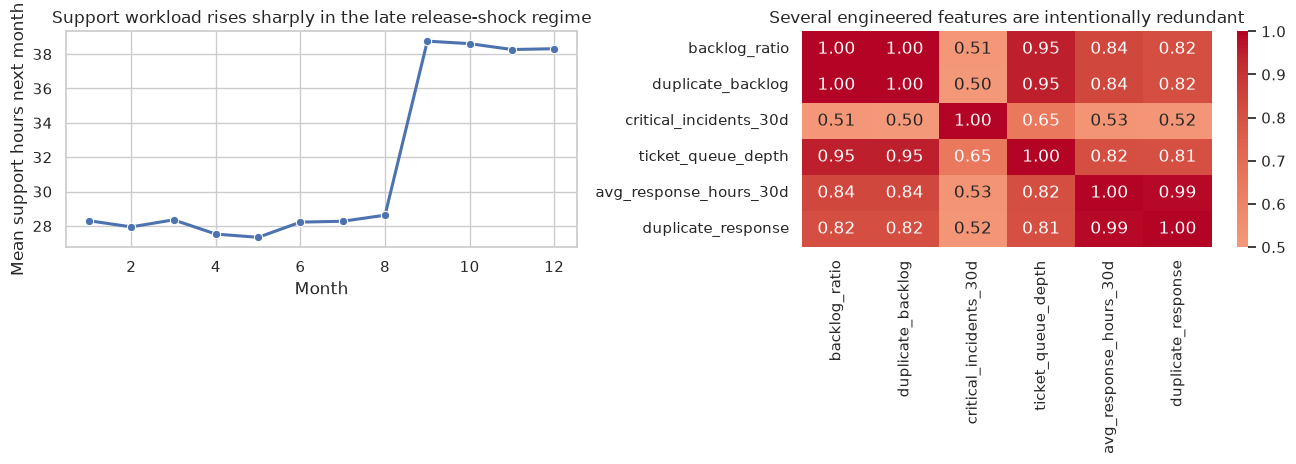

In [3]:
# Section focus: 2. Synthetic High-Dimensional Support-Forecasting Data.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


df = simulate_support_forecasting_data()

train = df[df["month"] <= 4].copy()
validation = df[df["month"].isin([5, 6, 7])].copy()
test = df[df["month"] >= 10].copy()

categorical_features = ["region", "tier", "industry"]
numeric_features = [
    column
    for column in df.columns
    if column not in categorical_features + ["account_id", "month", "support_hours_next_month"]
]

overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": len(df)},
        {"quantity": "Training rows", "value": len(train)},
        {"quantity": "Validation rows", "value": len(validation)},
        {"quantity": "Test rows", "value": len(test)},
        {"quantity": "Original numeric features", "value": len(numeric_features)},
        {
            "quantity": "Expanded numeric terms after degree-2 polynomial transform",
            "value": int((len(numeric_features) * (len(numeric_features) + 3)) / 2),
        },
        {"quantity": "Mean support hours", "value": round(df["support_hours_next_month"].mean(), 2)},
    ]
)

monthly_summary = (
    df.groupby("month", as_index=False)
    .agg(mean_support_hours=("support_hours_next_month", "mean"))
)

core_correlation = (
    df[
        [
            "backlog_ratio",
            "duplicate_backlog",
            "critical_incidents_30d",
            "ticket_queue_depth",
            "avg_response_hours_30d",
            "duplicate_response",
        ]
    ]
    .corr()
    .round(2)
)

smart_display(overview)
smart_display(monthly_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

sns.lineplot(data=monthly_summary, x="month", y="mean_support_hours", marker="o", linewidth=2.2, ax=axes[0])
axes[0].set_title("Support workload rises sharply in the late release-shock regime")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean support hours next month")

sns.heatmap(core_correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=axes[1])
axes[1].set_title("Several engineered features are intentionally redundant")

plt.tight_layout()
plt.show()


The dataset is *structurally redundant*, which is more informative than simply calling it high dimensional. `duplicate_backlog`, `ticket_queue_depth`, `sla_warning_rate`, and `renewal_risk_proxy` all reflect overlapping operational pressure. `duplicate_response` shadows response time. Several usage variables measure essentially the same adoption signal. Once we add pairwise interactions and squared terms, the model has many ways to explain the same outcome.

That is exactly where bias-variance thinking becomes practical. If a model has too much freedom relative to the amount of stable signal, it can fit the training data beautifully and still generalize poorly.


## 3. Bias-Variance Through Expanded Linear Models

To make overfitting visible, we fit an expanded linear design that includes pairwise interactions and squared terms. The unregularized model solves

$$
\hat{\beta}_{\text{OLS}} = \arg\min_{\beta} \sum_{i=1}^n (y_i - x_i^\top \beta)^2.
$$

Regularized variants modify that objective:

$$
\hat{\beta}_{\text{ridge}} = \arg\min_{\beta} \sum_{i=1}^n (y_i - x_i^\top \beta)^2 + \lambda \|\beta\|_2^2,
$$

$$
\hat{\beta}_{\text{lasso}} = \arg\min_{\beta} \sum_{i=1}^n (y_i - x_i^\top \beta)^2 + \lambda \|\beta\|_1,
$$

and elastic net mixes the two penalties. The key idea is simple. We deliberately accept some additional bias in exchange for lower variance and better out-of-sample stability.


,family,alpha,train_rmse,validation_rmse,test_rmse,active_coefficients,coefficient_l2_norm
0,Lasso,0.422,4.820,5.193,8.177,26,3.793
1,Elastic net,1.413,4.959,5.233,8.370,117,1.271
2,Ridge,15.849,3.369,6.060,8.735,749,9.536


,family,alpha,train_rmse,validation_rmse,test_rmse,active_coefficients,coefficient_l2_norm
0,OLS expanded,0.000,1.111,20.535,21.087,749,1718.161


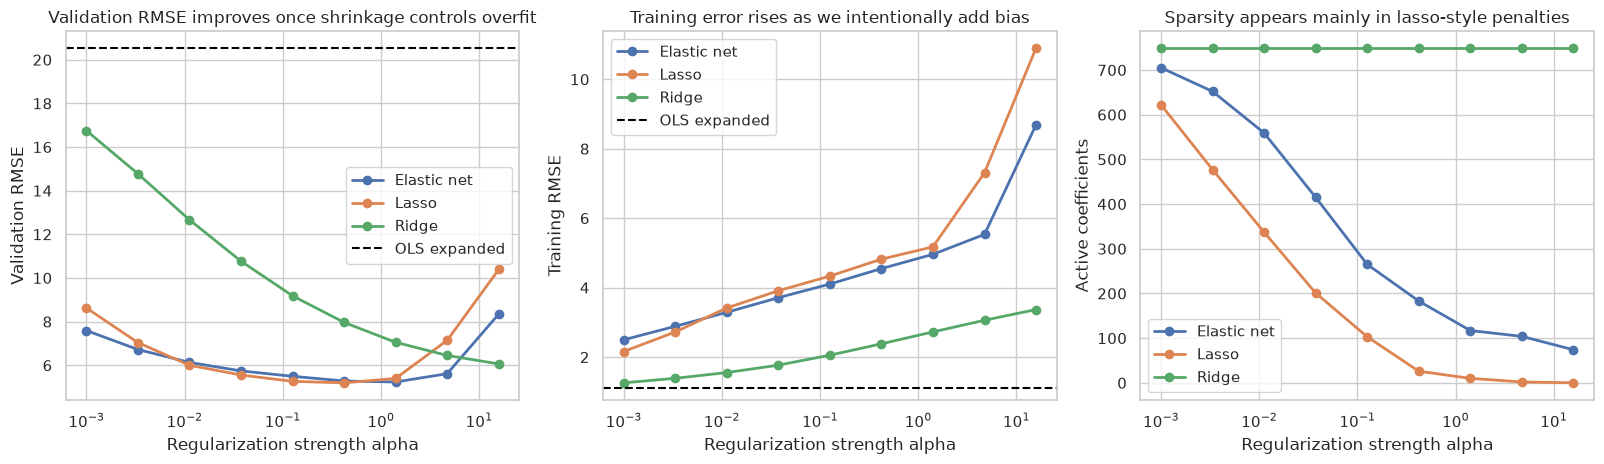

In [4]:
# Section focus: 3. Bias-Variance Through Expanded Linear Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


expanded_preprocessor = build_expanded_preprocessor(numeric_features, categorical_features)
alpha_grid = np.logspace(-3, 1.2, 9)
regularized_families = {
    "Ridge": lambda alpha: Ridge(alpha=float(alpha)),
    "Lasso": lambda alpha: Lasso(alpha=float(alpha), max_iter=15000),
    "Elastic net": lambda alpha: ElasticNet(alpha=float(alpha), l1_ratio=0.35, max_iter=15000),
}

curve_rows = []
for family, model_factory in regularized_families.items():
    for alpha in alpha_grid:
        pipeline = Pipeline(
            steps=[
                ("preprocessor", expanded_preprocessor),
                ("model", model_factory(alpha)),
            ]
        )
        pipeline.fit(train[categorical_features + numeric_features], train["support_hours_next_month"])

        train_predictions = pipeline.predict(train[categorical_features + numeric_features])
        validation_predictions = pipeline.predict(validation[categorical_features + numeric_features])
        test_predictions = pipeline.predict(test[categorical_features + numeric_features])
        coefficients = pipeline.named_steps["model"].coef_

        curve_rows.append(
            {
                "family": family,
                "alpha": float(alpha),
                "train_rmse": rmse(train["support_hours_next_month"], train_predictions),
                "validation_rmse": rmse(validation["support_hours_next_month"], validation_predictions),
                "test_rmse": rmse(test["support_hours_next_month"], test_predictions),
                "active_coefficients": int(np.sum(np.abs(coefficients) > 1e-8)),
                "coefficient_l2_norm": float(np.linalg.norm(coefficients)),
            }
        )

curve_results = pd.DataFrame(curve_rows)
best_by_family = (
    curve_results.loc[curve_results.groupby("family")["validation_rmse"].idxmin()]
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

ols_expanded = Pipeline(
    steps=[
        ("preprocessor", expanded_preprocessor),
        ("model", LinearRegression()),
    ]
)
ols_expanded.fit(train[categorical_features + numeric_features], train["support_hours_next_month"])
ols_train_predictions = ols_expanded.predict(train[categorical_features + numeric_features])
ols_validation_predictions = ols_expanded.predict(validation[categorical_features + numeric_features])
ols_test_predictions = ols_expanded.predict(test[categorical_features + numeric_features])

ols_summary = pd.DataFrame(
    [
        {
            "family": "OLS expanded",
            "alpha": 0.0,
            "train_rmse": rmse(train["support_hours_next_month"], ols_train_predictions),
            "validation_rmse": rmse(validation["support_hours_next_month"], ols_validation_predictions),
            "test_rmse": rmse(test["support_hours_next_month"], ols_test_predictions),
            "active_coefficients": int(np.sum(np.abs(ols_expanded.named_steps["model"].coef_) > 1e-8)),
            "coefficient_l2_norm": float(np.linalg.norm(ols_expanded.named_steps["model"].coef_)),
        }
    ]
)

smart_display(best_by_family.round(3))
smart_display(ols_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.8))

for family, family_frame in curve_results.groupby("family"):
    axes[0].plot(family_frame["alpha"], family_frame["validation_rmse"], marker="o", linewidth=2, label=family)
    axes[1].plot(family_frame["alpha"], family_frame["train_rmse"], marker="o", linewidth=2, label=family)

axes[0].axhline(ols_summary.loc[0, "validation_rmse"], color="black", linestyle="--", linewidth=1.5, label="OLS expanded")
axes[1].axhline(ols_summary.loc[0, "train_rmse"], color="black", linestyle="--", linewidth=1.5, label="OLS expanded")

lasso_like = curve_results[curve_results["family"].isin(["Lasso", "Elastic net"])]
for family, family_frame in lasso_like.groupby("family"):
    axes[2].plot(family_frame["alpha"], family_frame["active_coefficients"], marker="o", linewidth=2, label=family)

ridge_frame = curve_results[curve_results["family"] == "Ridge"]
axes[2].plot(ridge_frame["alpha"], ridge_frame["active_coefficients"], marker="o", linewidth=2, label="Ridge")

axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[2].set_xscale("log")

axes[0].set_title("Validation RMSE improves once shrinkage controls overfit")
axes[0].set_xlabel("Regularization strength alpha")
axes[0].set_ylabel("Validation RMSE")
axes[0].legend()

axes[1].set_title("Training error rises as we intentionally add bias")
axes[1].set_xlabel("Regularization strength alpha")
axes[1].set_ylabel("Training RMSE")
axes[1].legend()

axes[2].set_title("Sparsity appears mainly in lasso-style penalties")
axes[2].set_xlabel("Regularization strength alpha")
axes[2].set_ylabel("Active coefficients")
axes[2].legend()

plt.tight_layout()
plt.show()


Bias-Variance Through Expanded Linear Models gives a checkpoint for the decision workflow. The decision-relevant pattern is the one that changes the next workflow step.


### Discussion of the Regularization Paths

The expanded OLS model is the cautionary tale we wanted. Its training error is extraordinarily low, but validation and test error are disastrous. That is classic high-variance behavior: the model memorizes too much of the training sample once the interaction space becomes wide.

Ridge improves steadily as the penalty grows because it keeps the full feature set but suppresses unstable coefficient magnitudes. Lasso and elastic net go further by pruning the design. In this simulation, lasso achieves the best validation performance with a much smaller active set, which makes it a strong candidate when feature discipline matters.

Notice the operational meaning of these curves. We are not choosing regularization because it is fashionable. We are choosing it because the unregularized system would yield a misleadingly optimistic training story and an unreliable deployment story.


## 4. Tuned Expanded Models

The validation curves help us choose penalty strengths, but the practical question is what the tuned models buy us in final predictive performance and model size. We now compare the tuned expanded models directly and inspect the active lasso terms that survive shrinkage.


,model,split,rmse,mae,r_squared,active_coefficients
0,OLS expanded,Train,1.111,0.856,0.990,749
1,OLS expanded,Validation,20.535,15.600,-2.908,749
2,OLS expanded,Test,21.087,16.516,-1.174,749
3,Ridge tuned,Train,3.369,2.684,0.904,749
4,Ridge tuned,Validation,6.060,4.731,0.660,749
5,Ridge tuned,Test,8.735,7.173,0.627,749
6,Lasso tuned,Train,4.820,3.792,0.804,26
7,Lasso tuned,Validation,5.193,4.172,0.750,26
8,Lasso tuned,Test,8.177,6.776,0.673,26
9,Elastic net tuned,Train,4.959,3.894,0.793,117


,feature,coefficient
4,critical incidents 30d,3.057000
12,ticket queue depth,0.926000
263,prior escalation rate x high priority case mix,0.868000
571,high priority case mix x duplicate backlog,0.832000
50,active seats x ticket queue depth,0.796000
5,avg response hours 30d,0.779000
164,backlog ratio x high priority case mix,0.767000
150,backlog ratio x critical incidents 30d,0.467000
231,avg response hours 30d x high priority case mix,0.387000
38,active seats^2,0.327000


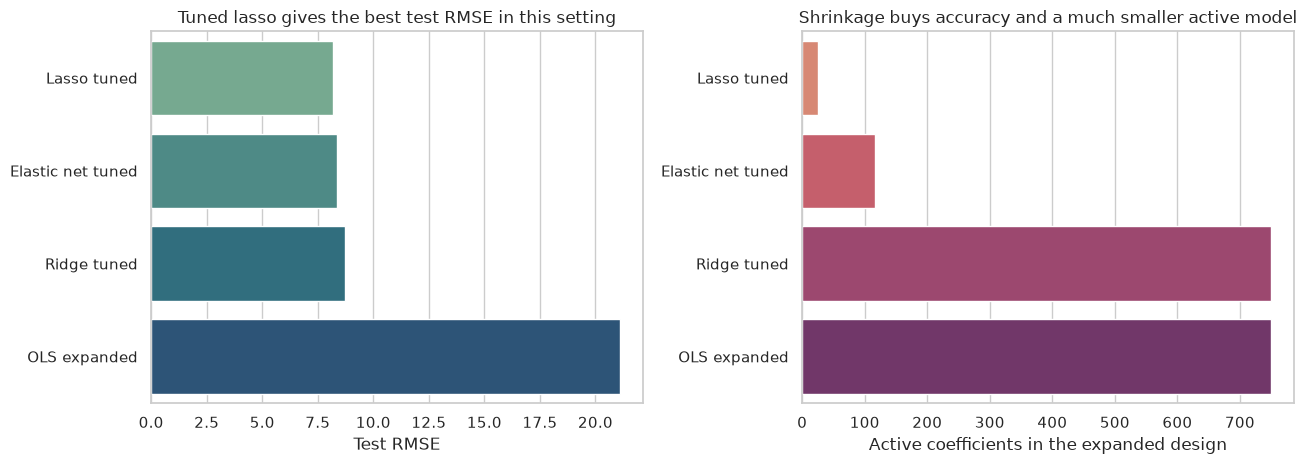

In [5]:
# Section focus: 4. Tuned Expanded Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


final_model_specs = {
    "OLS expanded": LinearRegression(),
    "Ridge tuned": Ridge(alpha=float(best_by_family.loc[best_by_family["family"] == "Ridge", "alpha"].iloc[0])),
    "Lasso tuned": Lasso(alpha=float(best_by_family.loc[best_by_family["family"] == "Lasso", "alpha"].iloc[0]), max_iter=15000),
    "Elastic net tuned": ElasticNet(
        alpha=float(best_by_family.loc[best_by_family["family"] == "Elastic net", "alpha"].iloc[0]),
        l1_ratio=0.35,
        max_iter=15000,
    ),
}

fitted_models = {}
comparison_rows = []
for model_name, model in final_model_specs.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", expanded_preprocessor),
            ("model", clone(model)),
        ]
    )
    pipeline.fit(train[categorical_features + numeric_features], train["support_hours_next_month"])
    fitted_models[model_name] = pipeline

    for split_name, frame in [("Train", train), ("Validation", validation), ("Test", test)]:
        predictions = pipeline.predict(frame[categorical_features + numeric_features])
        metrics = evaluate_regression(frame["support_hours_next_month"], predictions)
        comparison_rows.append(
            {
                "model": model_name,
                "split": split_name,
                **metrics,
                "active_coefficients": int(np.sum(np.abs(pipeline.named_steps["model"].coef_) > 1e-8)),
            }
        )

comparison = pd.DataFrame(comparison_rows)
test_comparison = comparison[comparison["split"] == "Test"].sort_values("rmse").reset_index(drop=True)

lasso_terms = coefficient_table(fitted_models["Lasso tuned"], categorical_features)
active_lasso_terms = lasso_terms.query("abs_coefficient > 1e-8").head(15)

smart_display(comparison.round(3))
smart_display(active_lasso_terms[["feature", "coefficient"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

sns.barplot(data=test_comparison, x="rmse", y="model", palette="crest", ax=axes[0])
axes[0].set_title("Tuned lasso gives the best test RMSE in this setting")
axes[0].set_xlabel("Test RMSE")
axes[0].set_ylabel("")

sns.barplot(data=test_comparison, x="active_coefficients", y="model", palette="flare", ax=axes[1])
axes[1].set_title("Shrinkage buys accuracy and a much smaller active model")
axes[1].set_xlabel("Active coefficients in the expanded design")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


The Tuned Expanded Models result matters when it changes the next move. Evidence matters here when it changes selection, diagnostics, thresholds, or limits.


### Discussion of the Final Models

Two patterns matter here.

First, the overfit from OLS does not disappear just because we evaluate on a later split. It remains dramatically worse than every regularized alternative. That is useful to see, because teams often keep an overfit model alive longer than they should simply because it looked excellent on the training sample.

Second, lasso achieves the best test performance *and* does so with a far smaller active coefficient set. Sparse selection has not discovered the one true generative story. The active-term table usually contains a mix of real signals, redundant proxies, and occasional noisy artifacts. The practical result is that shrinkage has turned a dangerous wide regression into a usable predictive system.


,account_id,month,region,tier,industry,support_hours_next_month
2193,A182,10,North America,Premium,SaaS,76.638


,model,mean_prediction,prediction_std,min_prediction,max_prediction
0,Lasso tuned,72.044,1.631,69.186,74.664
1,OLS expanded,74.131,18.951,52.509,122.139
2,Ridge tuned,68.680,3.862,62.866,75.827


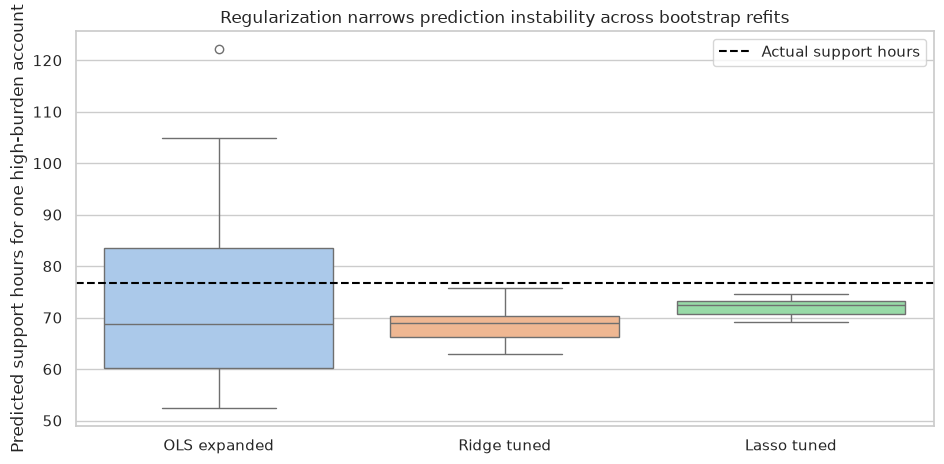

In [6]:
# Section focus: Discussion of the Final Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


reference_case = (
    test.sort_values("support_hours_next_month", ascending=False)
    .iloc[[10]][["account_id", "month", "region", "tier", "industry", "support_hours_next_month"] + numeric_features]
)
reference_overview = reference_case[["account_id", "month", "region", "tier", "industry", "support_hours_next_month"]]

bootstrap_predictions = []
bootstrap_models = {
    "OLS expanded": final_model_specs["OLS expanded"],
    "Ridge tuned": final_model_specs["Ridge tuned"],
    "Lasso tuned": final_model_specs["Lasso tuned"],
}

for bootstrap_index in range(20):
    sampled_train = train.sample(frac=1, replace=True, random_state=100 + bootstrap_index)
    for model_name, model in bootstrap_models.items():
        pipeline = Pipeline(
            steps=[
                ("preprocessor", expanded_preprocessor),
                ("model", clone(model)),
            ]
        )
        pipeline.fit(sampled_train[categorical_features + numeric_features], sampled_train["support_hours_next_month"])
        prediction = pipeline.predict(reference_case[categorical_features + numeric_features])[0]
        bootstrap_predictions.append(
            {
                "model": model_name,
                "predicted_support_hours": prediction,
            }
        )

bootstrap_predictions = pd.DataFrame(bootstrap_predictions)
bootstrap_summary = (
    bootstrap_predictions.groupby("model", as_index=False)
    .agg(
        mean_prediction=("predicted_support_hours", "mean"),
        prediction_std=("predicted_support_hours", "std"),
        min_prediction=("predicted_support_hours", "min"),
        max_prediction=("predicted_support_hours", "max"),
    )
)

smart_display(reference_overview)
smart_display(bootstrap_summary.round(3))

fig, ax = plt.subplots(figsize=(9.6, 4.8))
sns.boxplot(data=bootstrap_predictions, x="model", y="predicted_support_hours", palette="pastel", ax=ax)
ax.axhline(reference_case["support_hours_next_month"].iloc[0], color="black", linestyle="--", linewidth=1.5, label="Actual support hours")
ax.set_title("Regularization narrows prediction instability across bootstrap refits")
ax.set_xlabel("")
ax.set_ylabel("Predicted support hours for one high-burden account")
ax.legend()
plt.tight_layout()
plt.show()


Read Discussion of the Final Models as a decision checkpoint. A decision-centered reading asks what the result would make us do differently.


### Discussion of Bias and Variance

This bootstrap experiment makes the tradeoff tangible. The OLS model has worse average test error and much less stable case-level predictions. Its predictions for the *same operational case* move wildly across resampled training sets. Ridge narrows that spread substantially. Lasso narrows it further while remaining competitive on accuracy.

That is the real decision-science value of regularization. The value is system stability under plausible perturbations of the data-generation process we happened to observe, not a single better holdout score.


## 5. Feature Selection Strategies

Regularization and feature selection overlap, but they are not identical. Regularization controls coefficient freedom inside a model. Feature selection explicitly chooses a smaller input set.

The three broad families are:

| Strategy | Core idea | Strength | Weakness |
|---|---|---|---|
| Filter | Rank variables without repeatedly fitting the full predictive model | Fast and model-agnostic | Can miss interactions or grouped effects |
| Wrapper | Search feature subsets using repeated model fits | Often closely aligned with predictive performance | Computationally expensive |
| Embedded | Let the learning algorithm perform selection internally | Efficient and tightly integrated with fitting | Selection may be unstable when signals are correlated |

For a fair comparison, the compact models below always keep the categorical context variables and differ only in which numeric features are retained.


,strategy,selected_numeric_features,rmse,mae,r_squared
0,All original features + ridge,38,8.107000,6.707000,0.679000
1,Wrapper RFE top-10 + ridge,10,8.118000,6.678000,0.678000
2,Filter top-10 + ridge,10,8.173000,6.737000,0.673000
3,Embedded lasso-selected + ridge,12,8.189000,6.804000,0.672000


,strategy,features
0,All original features + ridge,"active_seats, usage_ratio, adoption_breadth, backlog_ratio, critical_incidents_30d, avg_response_hours_30d, prior_escalation_rate, csat_score, release_shock, login_7d, login_30d, feature_adoption_score, ticket_queue_depth, ticket_age_p90, sla_warning_rate, unresolved_bug_flags, sponsor_engagement, renewal_risk_proxy, high_priority_case_mix, weekend_activity, duplicate_backlog, duplicate_usage, duplicate_response, noise_1, noise_2, noise_3, noise_4, noise_5, noise_6, noise_7, noise_8, noise_9, noise_10, noise_11, noise_12, noise_13, noise_14, noise_15"
1,Filter top-10 + ridge,"ticket_queue_depth, duplicate_backlog, prior_escalation_rate, backlog_ratio, high_priority_case_mix, critical_incidents_30d, avg_response_hours_30d, duplicate_response, sla_warning_rate, ticket_age_p90"
2,Wrapper RFE top-10 + ridge,"adoption_breadth, backlog_ratio, critical_incidents_30d, avg_response_hours_30d, prior_escalation_rate, csat_score, feature_adoption_score, high_priority_case_mix, duplicate_backlog, duplicate_response"
3,Embedded lasso-selected + ridge,"active_seats, backlog_ratio, critical_incidents_30d, avg_response_hours_30d, prior_escalation_rate, feature_adoption_score, ticket_queue_depth, unresolved_bug_flags, high_priority_case_mix, duplicate_backlog, noise_7, noise_8"


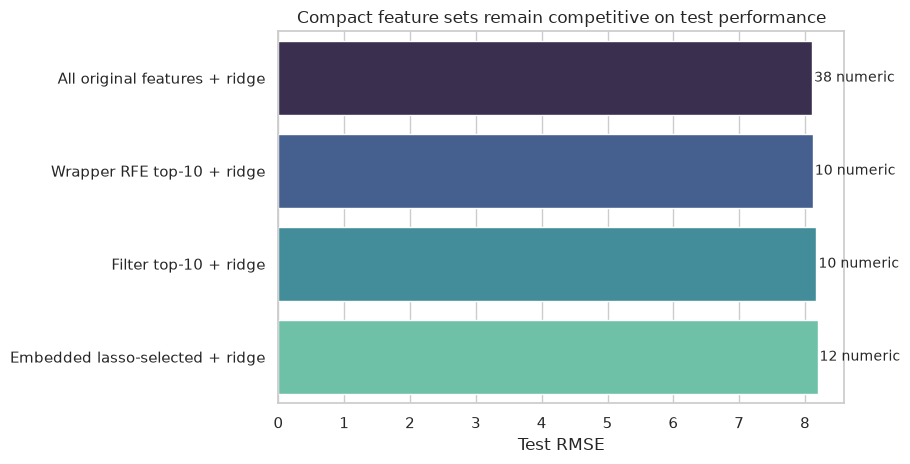

In [7]:
# Section focus: 5. Feature Selection Strategies.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def fit_original_ridge(selected_numeric_features, alpha=5.0):
    """Fit the original ridge model or object used in the 06. Regularization, Bias-Variance, and Feature Selection analysis.
    
    Parameters
    ----------
    selected_numeric_features : object
        Column or variable name used to select information from the input table.
    alpha : object
        Regularization, smoothing, or significance parameter used by the calculation.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    preprocessor = build_original_preprocessor(selected_numeric_features, categorical_features)
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge(alpha=alpha)),
        ]
    )
    pipeline.fit(train[selected_numeric_features + categorical_features], train["support_hours_next_month"])
    predictions = pipeline.predict(test[selected_numeric_features + categorical_features])
    metrics = evaluate_regression(test["support_hours_next_month"], predictions)
    return pipeline, metrics


selection_rows = []
selected_feature_sets = []

_, all_original_metrics = fit_original_ridge(numeric_features)
selection_rows.append({"strategy": "All original features + ridge", "selected_numeric_features": len(numeric_features), **all_original_metrics})
selected_feature_sets.append({"strategy": "All original features + ridge", "features": ", ".join(numeric_features)})

mutual_information_scores = mutual_info_regression(train[numeric_features], train["support_hours_next_month"], random_state=0)
filter_ranking = pd.DataFrame({"feature": numeric_features, "mutual_information": mutual_information_scores}).sort_values(
    "mutual_information", ascending=False
)
filter_features = filter_ranking.head(10)["feature"].tolist()
_, filter_metrics = fit_original_ridge(filter_features)
selection_rows.append({"strategy": "Filter top-10 + ridge", "selected_numeric_features": len(filter_features), **filter_metrics})
selected_feature_sets.append({"strategy": "Filter top-10 + ridge", "features": ", ".join(filter_features)})

wrapper_selector = RFE(estimator=Ridge(alpha=5.0), n_features_to_select=10, step=1)
wrapper_selector.fit(train[numeric_features], train["support_hours_next_month"])
wrapper_features = [feature for feature, keep in zip(numeric_features, wrapper_selector.get_support()) if keep]
_, wrapper_metrics = fit_original_ridge(wrapper_features)
selection_rows.append({"strategy": "Wrapper RFE top-10 + ridge", "selected_numeric_features": len(wrapper_features), **wrapper_metrics})
selected_feature_sets.append({"strategy": "Wrapper RFE top-10 + ridge", "features": ", ".join(wrapper_features)})

scaler_for_embedded = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
X_train_original = scaler_for_embedded.fit_transform(train[numeric_features])
X_validation_original = scaler_for_embedded.transform(validation[numeric_features])

embedded_alpha_grid = np.logspace(-3, 0.5, 10)
embedded_rows = []
embedded_models = {}
for alpha in embedded_alpha_grid:
    lasso_original = Lasso(alpha=float(alpha), max_iter=10000)
    lasso_original.fit(X_train_original, train["support_hours_next_month"])
    validation_predictions = lasso_original.predict(X_validation_original)
    embedded_rows.append(
        {
            "alpha": float(alpha),
            "validation_rmse": rmse(validation["support_hours_next_month"], validation_predictions),
            "selected_numeric_features": int(np.sum(np.abs(lasso_original.coef_) > 1e-8)),
        }
    )
    embedded_models[float(alpha)] = lasso_original

embedded_results = pd.DataFrame(embedded_rows)
best_embedded_row = embedded_results.loc[embedded_results["validation_rmse"].idxmin()]
best_embedded_model = embedded_models[float(best_embedded_row["alpha"])]
embedded_features = [feature for feature, coef in zip(numeric_features, best_embedded_model.coef_) if abs(coef) > 1e-8]
_, embedded_metrics = fit_original_ridge(embedded_features)
selection_rows.append({"strategy": "Embedded lasso-selected + ridge", "selected_numeric_features": len(embedded_features), **embedded_metrics})
selected_feature_sets.append({"strategy": "Embedded lasso-selected + ridge", "features": ", ".join(embedded_features)})

selection_comparison = pd.DataFrame(selection_rows).sort_values("rmse").reset_index(drop=True)
selected_feature_sets = pd.DataFrame(selected_feature_sets)

smart_display(selection_comparison.round(3))
smart_display(selected_feature_sets)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
plot_frame = selection_comparison.copy()
plot = sns.barplot(data=plot_frame, x="rmse", y="strategy", palette="mako", ax=ax)
for patch, count in zip(plot.patches, plot_frame["selected_numeric_features"]):
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    ax.text(width + 0.03, y, f"{count} numeric", va="center", fontsize=10)
ax.set_title("Compact feature sets remain competitive on test performance")
ax.set_xlabel("Test RMSE")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


The practical question in Feature Selection Strategies is simple. What would this result make the analyst do differently?


,feature,selection_frequency
0,active_seats,1.000
1,avg_response_hours_30d,1.000
2,critical_incidents_30d,1.000
3,prior_escalation_rate,1.000
4,high_priority_case_mix,1.000
5,ticket_queue_depth,0.967
6,noise_7,0.700
7,duplicate_backlog,0.667
8,feature_adoption_score,0.667
9,unresolved_bug_flags,0.600


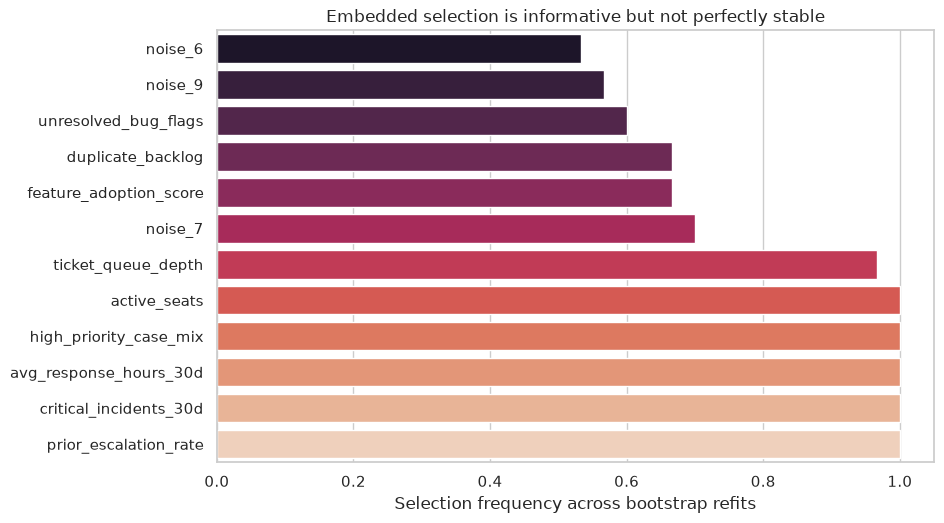

In [8]:
# Section focus: 5. Feature Selection Strategies.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


selection_frequency_counts = pd.Series(0.0, index=numeric_features)
embedded_alpha = float(best_embedded_row["alpha"])

for bootstrap_index in range(30):
    sampled_train = train.sample(frac=1, replace=True, random_state=400 + bootstrap_index)
    X_sampled = scaler_for_embedded.fit_transform(sampled_train[numeric_features])
    y_sampled = sampled_train["support_hours_next_month"].to_numpy()

    lasso_bootstrap = Lasso(alpha=embedded_alpha, max_iter=10000)
    lasso_bootstrap.fit(X_sampled, y_sampled)
    selection_frequency_counts += (np.abs(lasso_bootstrap.coef_) > 1e-8)

selection_frequency = (
    (selection_frequency_counts / 30)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "selection_frequency"})
)

top_selection_frequency = selection_frequency.head(12)
smart_display(top_selection_frequency.round(3))

fig, ax = plt.subplots(figsize=(9.6, 5.4))
sns.barplot(data=top_selection_frequency.sort_values("selection_frequency"), x="selection_frequency", y="feature", palette="rocket", ax=ax)
ax.set_title("Embedded selection is informative but not perfectly stable")
ax.set_xlabel("Selection frequency across bootstrap refits")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Use the Feature Selection Strategies output to decide what the analysis should do next. Focus on the part of the output that would alter a model, diagnostic, threshold, or guardrail.


### Discussion of Feature Selection

The compact models perform surprisingly well. Even after reducing the numeric feature set substantially, their test errors remain close to the full original-feature ridge model. That is encouraging for deployment, because smaller feature sets usually mean simpler data contracts, easier validation checks, and fewer opportunities for upstream breakage.

But the stability plot is just as important as the performance table. Some core workload variables appear in almost every bootstrap refit, while correlated alternatives rotate in and out. A few noise features can also slip into the selected set in finite samples. That is exactly why sparse selection should be interpreted as a *predictive convenience*, not as a definitive statement of substantive importance.


## 6. Practical Checklist

| Question | Why it matters |
|---|---|
| Is the design matrix wider or more redundant than the business story really requires? | Overfit often begins with unnecessary representational freedom |
| Are we tuning penalty strength on validation data rather than intuition? | Regularization is only useful if the amount is chosen empirically |
| Does the unregularized model look implausibly good on training data? | That is often the first visible sign of high variance |
| Are sparse coefficients being interpreted as causal importance? | Predictive selection does not identify intervention drivers |
| How much accuracy do we lose when we enforce a compact feature set? | Maintainability sometimes justifies a tiny performance sacrifice |
| Are selected features stable across resamples? | Unstable selection can make governance stories brittle |
| Do feature choices reduce deployment complexity in a meaningful way? | Fewer variables should translate into simpler operational ownership |

A regularized model still needs validation, and a sparse model still needs interpretability checks. The point is to build a predictive system whose freedom is appropriate for the stability of the signal we actually have.


## Wrap-Up

This notebook used a deliberately wide service-operations forecasting problem to show why regularization is a practical decision-science tool. The expanded OLS model overfit badly. Ridge, lasso, and elastic net each improved generalization by shrinking that freedom, and lasso delivered the strongest validation and test behavior in this particular simulation while producing a much smaller active model.

Feature selection then added a second layer of discipline. Filter, wrapper, and embedded strategies all produced compact models whose performance stayed close to the full original-feature ridge benchmark. But the bootstrap selection-frequency analysis reminded us that sparse selection can wobble under correlated signals and finite samples. That is why good model governance cares about stability and maintainability in addition to headline accuracy.

## References
- Hoerl, A. E., & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems.* *Technometrics, 12*(1), 55-67. [https://doi.org/10.1080/00401706.1970.10488634](https://doi.org/10.1080/00401706.1970.10488634)
- Tibshirani, R. (1996). *Regression Shrinkage and Selection Via the Lasso.* *Journal of the Royal Statistical Society: Series B (Statistical Methodology), 58*(1), 267-288. [https://doi.org/10.1111/j.2517-6161.1996.tb02080.x](https://doi.org/10.1111/j.2517-6161.1996.tb02080.x)
- Zou, H., & Hastie, T. (2005). *Regularization and Variable Selection Via the Elastic Net.* *Journal of the Royal Statistical Society: Series B (Statistical Methodology), 67*(2), 301-320. [https://doi.org/10.1111/j.1467-9868.2005.00503.x](https://doi.org/10.1111/j.1467-9868.2005.00503.x)
- Li, J., Cheng, K., Wang, S., et al. (2018). *Feature Selection.* *ACM Computing Surveys, 50*(6), 1-45. [https://doi.org/10.1145/3136625](https://doi.org/10.1145/3136625)
